- mask defocus & imaging defocus 为 0 时, pupil phase=0


In [2]:
from simulation import *

-53.49302342661134,84.41551099822982


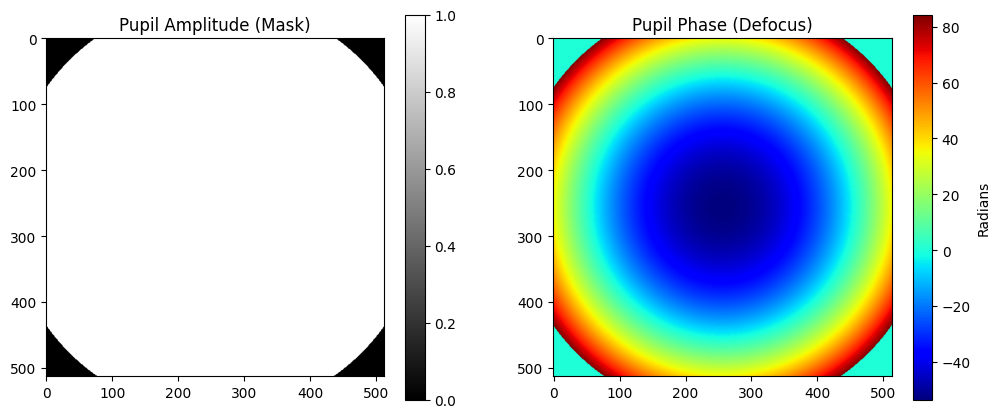

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def phase_angle(kx, ky, imaging_defocus, zero_focus_offset, mask_defocus, reduction, n = 1):
    kx_2 = kx**2
    ky_2 = ky**2
    n_2 = n**2
    return -np.sqrt(n_2 - (kx_2 + ky_2)) * imaging_defocus - np.sqrt(n_2 - (kx_2 + ky_2) / (reduction**2)) * (zero_focus_offset + mask_defocus)

def generate_pupil(size, wavelength, imaging_defocus, zero_focus_offset, mask_defocus, reduction):
    # 1. 创建坐标网格 (-1 到 1)
    x = np.arange(-(size//2), (size//2) + 1) * (2.0 / (size - 1))
    y = np.arange(-(size//2), (size//2) + 1) * (2.0 / (size - 1))
    xx, yy = np.meshgrid(x, y)
    
    mask = (xx**2 + yy**2) <= 1.5
    k0 = 2*np.pi/wavelength
    phase = phase_angle(xx*mask*k0, yy*mask*k0 ,imaging_defocus, zero_focus_offset, mask_defocus, reduction)
    
    pupil = mask * np.exp(1j * phase)
    phase = mask * np.angle(pupil) * 180/np.pi
    return pupil, phase

pupil_complex, phase_map = generate_pupil(512, 13.5, 13.5,0,0, 1)

# --- 可视化 ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Pupil Amplitude (Mask)")
plt.imshow(np.abs(pupil_complex), cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"Pupil Phase (Defocus)")
plt.imshow(phase_map, cmap='jet')
plt.colorbar(label='Radians')
print(f"{np.min(phase_map)},{np.max(phase_map)}")
plt.show()